<a href="https://colab.research.google.com/github/Mangesh0309/Neural-Networks/blob/main/Xception_Transfer_Learning_Corrected.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Xception Transfer Learning - Image Classification
This notebook demonstrates how to use Xception with transfer learning on a small custom dataset.

In [1]:
# 📦 1. Import libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import os


### Dataset Link :- https://drive.google.com/file/d/1TCU1nqgIe1R_dW6LTkRxlufHlCCazyJl/view?usp=sharing

In [2]:
import gdown

# Google Drive file ID
file_id = "1TCU1nqgIe1R_dW6LTkRxlufHlCCazyJl"
# Download destination filename
output = "myfile.zip"

# Download the file
gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1TCU1nqgIe1R_dW6LTkRxlufHlCCazyJl
From (redirected): https://drive.google.com/uc?id=1TCU1nqgIe1R_dW6LTkRxlufHlCCazyJl&confirm=t&uuid=81c0cac9-36c7-4982-95f0-29eaa1135a6f
To: /content/myfile.zip
100%|██████████| 63.9M/63.9M [00:00<00:00, 69.9MB/s]


'myfile.zip'

In [3]:
import zipfile

with zipfile.ZipFile("myfile.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [4]:
# 2. Define paths (update with your dataset path)
train_dir = "/content/dataset/train"
val_dir = "/content/dataset/valid"
img_size = 299
batch_size = 32


In [5]:
# 3. Data generators
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.xception.preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.xception.preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)


Found 1275 images belonging to 2 classes.
Found 364 images belonging to 2 classes.


In [6]:
#4. Load base model
base_model = Xception(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
base_model.trainable = False


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
base_model.summary()

Model: "xception"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 149, 149,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 149, 149,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 147, 147,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 147, 147,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 147, 147,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 147, 147,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 147, 147,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 147, 147,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 147, 147,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 147, 147,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 74, 74,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 74, 74,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 74, 74,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 74, 74,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 74, 74,    │          0 │ add[0][0]       

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,861,480 (79.58 MB)

In [8]:
#5. Add custom classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)


In [9]:
#6. Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [10]:
#7. Train the model (initial training with frozen base)
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)


Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 147s 3s/step - accuracy: 0.5608 - loss: 0.6832 - val_accuracy: 0.8571 - val_loss: 0.5369
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 35s 878ms/step - accuracy: 0.7804 - loss: 0.5239 - val_accuracy: 0.9121 - val_loss: 0.4130
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 35s 862ms/step - accuracy: 0.8588 - loss: 0.4396 - val_accuracy: 0.9121 - val_loss: 0.3402
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 35s 864ms/step - accuracy: 0.8808 - loss: 0.3808 - val_accuracy: 0.9203 - val_loss: 0.2934
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 36s 893ms/step - accuracy: 0.8816 - loss: 0.3482 - val_accuracy: 0.9203 - val_loss: 0.2648
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 36s 905ms/step - accuracy: 0.8996 - loss: 0.3178 - val_accuracy: 0.9203 - val_loss: 0.2436
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 36s 899ms/step - accuracy: 0.8925 - loss: 0.2988 - val_accuracy: 0.9176 - val_loss: 0.2285
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 35s 874ms/step - accuracy: 0.9027 - loss: 0.2812 - val_accura

In [ ]:
# 8. Fine-tune Unfreeze and fine-tune (optional)
# base_model.trainable = True
# model.compile(optimizer=Adam(learning_rate=1e-5),
#               loss='categorical_crossentropy',
#               metrics=['accuracy'])

# fine_tune_history = model.fit(
#     train_generator,
#     epochs=5,
#     validation_data=val_generator
# )


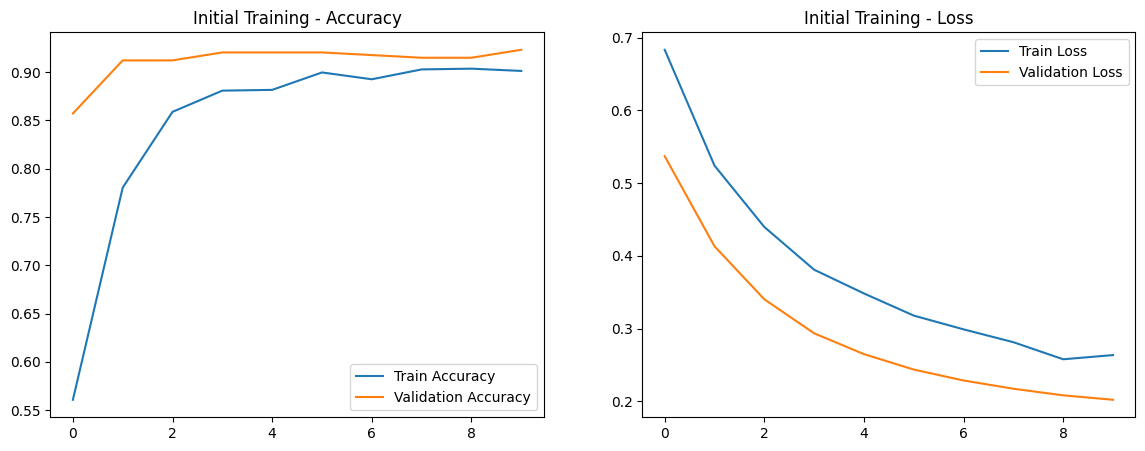

In [11]:
#9. Plot training history
def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Train Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.legend()

    plt.show()

plot_history(history, "Initial Training")
#plot_history(fine_tune_history, "Fine Tuning")


In [12]:
#10. Save model
model.save("xception_transfer_learning_model.h5")


In [13]:

model.save("xception_transfer_learning_model.keras")


In [14]:
from tensorflow.keras.models import load_model

model = load_model("xception_transfer_learning_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 4 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [15]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

def predict_image(model, image_path):
    img = load_img(image_path, target_size=(299, 299))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.xception.preprocess_input(img_array)

    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions, axis=1)
    class_indices = {v: k for k, v in train_generator.class_indices.items()}
    return class_indices[predicted_class[0]]



In [16]:
# Example usage
image_path = "/content/dataset/test/daisy/14613443462_d4ed356201_jpg.rf.76462b3f0cb5ca5a0b4b7c9894feb91c.jpg"  # Update path accordingly
predicted_label = predict_image(model, image_path)
print("Predicted Label:", predicted_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step
Predicted Label: daisy


In [17]:
# Example usage
image_path = "/content/dataset/test/dandelion/14060367700_fe87e99b6a_m_jpg.rf.eaf8222cde370b2ebb4d6a1378ec07b1.jpg"  # Update path accordingly
predicted_label = predict_image(model, image_path)
print("Predicted Label:", predicted_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted Label: dandelion
